# Physical Axicon Beam Study

Stage C notebook for the physical axicon route. This route does not use a holographic blaze carrier or first-order selection in the same sense as the SLM hologram route; it has separate aperture, efficiency, alignment, and hardware assumptions.

In [1]:
from dataclasses import replace
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_regime, vbb_train_viz, viz_fields
from vbb_study.equations import objective_pupil as objp
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
base = replace(bt.default_config(PRESET), generation_method="physical")
out_fig = PATHS["figures"] / "stage_c"
out_csv = PATHS["csv"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
out_csv.mkdir(parents=True, exist_ok=True)

def _objective_fields(cfg):
    return {
        "objective_NA": float(cfg.objective.NA),
        "objective_f_eff_mm": float(cfg.objective.f_eff_m / bt.mm),
        "pupil_radius_mm": float(cfg.objective.pupil_radius_m / bt.mm),
        "pupil_clipped_fraction": objp.gaussian_clipping_power_fraction(
            cfg.laser.beam_radius_on_slm_m,
            cfg.objective.pupil_radius_m,
        ),
    }

def _hardware_status(path_label):
    return "future_hardware_required" if path_label == "lab" else "simulation_only"


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [2]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='lab_realism',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    # blaze_period_px=20,  # holographic route only
)

# Wire control parameters into `base` so downstream cells use them.
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


,control,value
0,stage,lab_realism
1,run_mode,balanced
2,save_outputs,False
3,use_canonical_outputs,True
4,allow_publication_export,False
5,notes,Edit for exploration; keep QA labels/caveats v...
6,ell,3
7,target_core_diameter_um,3.0
8,target_bessel_length_um,150.0
9,objective_NA,0.45


## Interactive Quicklook

Adjust sliders and click **Update plots** to explore parameter combinations instantly.
This cell runs a `preset='fast'` preview only — it does not write any saved outputs and does not affect the locked study cells below.

- **ell** — vortex charge (0 = scalar Bessel, ≥1 = vortex ring)
- **core diam** — equivalent J₀ first-zero target diameter
- **zone length** — target non-diffracting propagation length
- **objective NA** — changes demagnification and pupil size
- **SLM2 levels** — quantization of the SLM2 conjugate mask (0 = ideal continuous)


In [3]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='physical', preset='fast')
display(_panel)


In [4]:
rows = []
for regime in ("general", "limits"):
    cfg = vbb_regime.config_for_regime(base, regime)
    ideal_cfg = replace(cfg, physical_axicon=replace(cfg.physical_axicon, slm2_stroke_levels=None, slm2_conjugate_mode="preserve_vortex"))
    lab_cfg = replace(cfg, physical_axicon=replace(cfg.physical_axicon, slm2_stroke_levels=256, slm2_conjugate_mode="preserve_vortex"))
    for label, run_cfg in [("ideal", ideal_cfg), ("lab", lab_cfg)]:
        result = bt.run_case(run_cfg, preset=PRESET, path="ideal", case_id=f"{regime}_physical_{label}")
        m = result["metrics"]
        meta = result["axicon_metadata"]
        design = bt.compute_design_from_config(run_cfg)
        surface = result["surface_field"]
        measured_winding = viz_fields.phase_winding(
            surface.Ex, surface.grid, float(design.vortex_main_ring_radius_m)
        )
        winding_error = abs(measured_winding - int(design.ell))
        if winding_error >= 0.1:
            raise RuntimeError(
                f"{regime}/{label} physical winding {measured_winding:.6g} "
                f"does not match requested ell={design.ell}"
            )
        row = {
            "case_id": f"{regime}_physical_{label}",
            "regime": regime,
            "path": "ideal",
            "route_variant": label,
            "physical_axicon_phase": meta.get("physical_axicon_phase"),
            "physical_axicon_pixelated": meta.get("physical_axicon_pixelated"),
            "physical_axicon_base_angle_deg": meta.get("gamma_deg", design.gamma_slm_deg),
            "equivalent_kr_m_inv": result["axicon_result"].k_r,
            "predicted_bessel_length_um": design.target_bessel_length_m / bt.um,
            "canonical_zone_um": m["canonical_zone_um"],
            "strict_bessel_region_um": m["strict_bessel_region_um"],
            "feature_diameter_um": m["feature_diameter_um"],
            "peak_fluence_J_cm2": m["peak_fluence_J_cm2"],
            "side_to_core_peak_ratio": m["side_to_core_peak_ratio"],
            "first_order_selected_fraction": m.get("first_order_selected_fraction"),
            "requested_vortex_charge": int(design.ell),
            "measured_winding": float(measured_winding),
            "winding_error": float(winding_error),
            "winding_pass": bool(winding_error < 0.1),
            "slm2_conjugate_mode": str(run_cfg.physical_axicon.slm2_conjugate_mode),
            "vortex_removal_acknowledged": bool(run_cfg.physical_axicon.allow_vortex_removal),
            "propagation_power_drift_fraction": m.get("propagation_power_drift_fraction"),
            "propagation_power_label": m.get("propagation_power_label"),
            "quantitative_metrics_valid": m.get("quantitative_metrics_valid"),
            "quantitative_metrics_invalid_reason": m.get("quantitative_metrics_invalid_reason"),
            "slm2_residual_phase_rms_before_rad": meta.get("slm2_residual_phase_rms_before_rad"),
            "slm2_residual_phase_rms_after_rad": meta.get("slm2_residual_phase_rms_after_rad"),
            "validity_valid": result["validity_report"]["valid"],
            **_objective_fields(run_cfg),
        }
        lab_schema.annotate_lab_realism_row(
            row,
            generation_method="physical_axicon",
            model_level="hardware_route",
            hardware_status=_hardware_status(label),
            plane_label="surface_plane",
            coordinate_frame="surface_plane_air_um",
            run_id=RUN_ID,
            preset=PRESET,
            path="ideal",
        )
        rows.append(row)
summary = lab_schema.ordered_lab_realism_frame(rows)
summary.to_csv(out_csv / "physical_axicon_design_summary.csv", index=False)
summary


,run_id,generated_at_utc,source_schema_version,case_id,preset,path,generation_method,model_level,hardware_status,plane_label,...,physical_axicon_pixelated,physical_axicon_base_angle_deg,equivalent_kr_m_inv,predicted_bessel_length_um,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,slm2_residual_phase_rms_before_rad,slm2_residual_phase_rms_after_rad,validity_valid
0,20260715T175904Z,2026-07-15T17:59:04.345766+00:00,1.0.0,general_physical_ideal,fast,ideal,physical_axicon,hardware_route,simulation_only,surface_plane,...,False,0.242851,1.603333e+06,150.0,5.277632,2.682452,0.426510,0.206818,3.530373e-16,True
1,20260715T175906Z,2026-07-15T17:59:06.450844+00:00,1.0.0,general_physical_lab,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,...,False,0.242851,1.603333e+06,150.0,5.277632,2.684096,0.426265,0.206818,7.165301e-03,True
2,20260715T175908Z,2026-07-15T17:59:08.482249+00:00,1.0.0,limits_physical_ideal,fast,ideal,physical_axicon,hardware_route,simulation_only,surface_plane,...,False,1.092704,2.405000e+06,300.0,3.267105,3.261889,0.471303,0.135671,3.581474e-16,True
3,20260715T175910Z,2026-07-15T17:59:10.525103+00:00,1.0.0,limits_physical_lab,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,...,False,1.092704,2.405000e+06,300.0,3.267105,3.261629,0.470855,0.135671,7.080284e-03,True


WindowsPath('C:/PhD/Code/Publication_Study/outputs/figures/stage_c/stage_c_sampling_qa_limits.png')

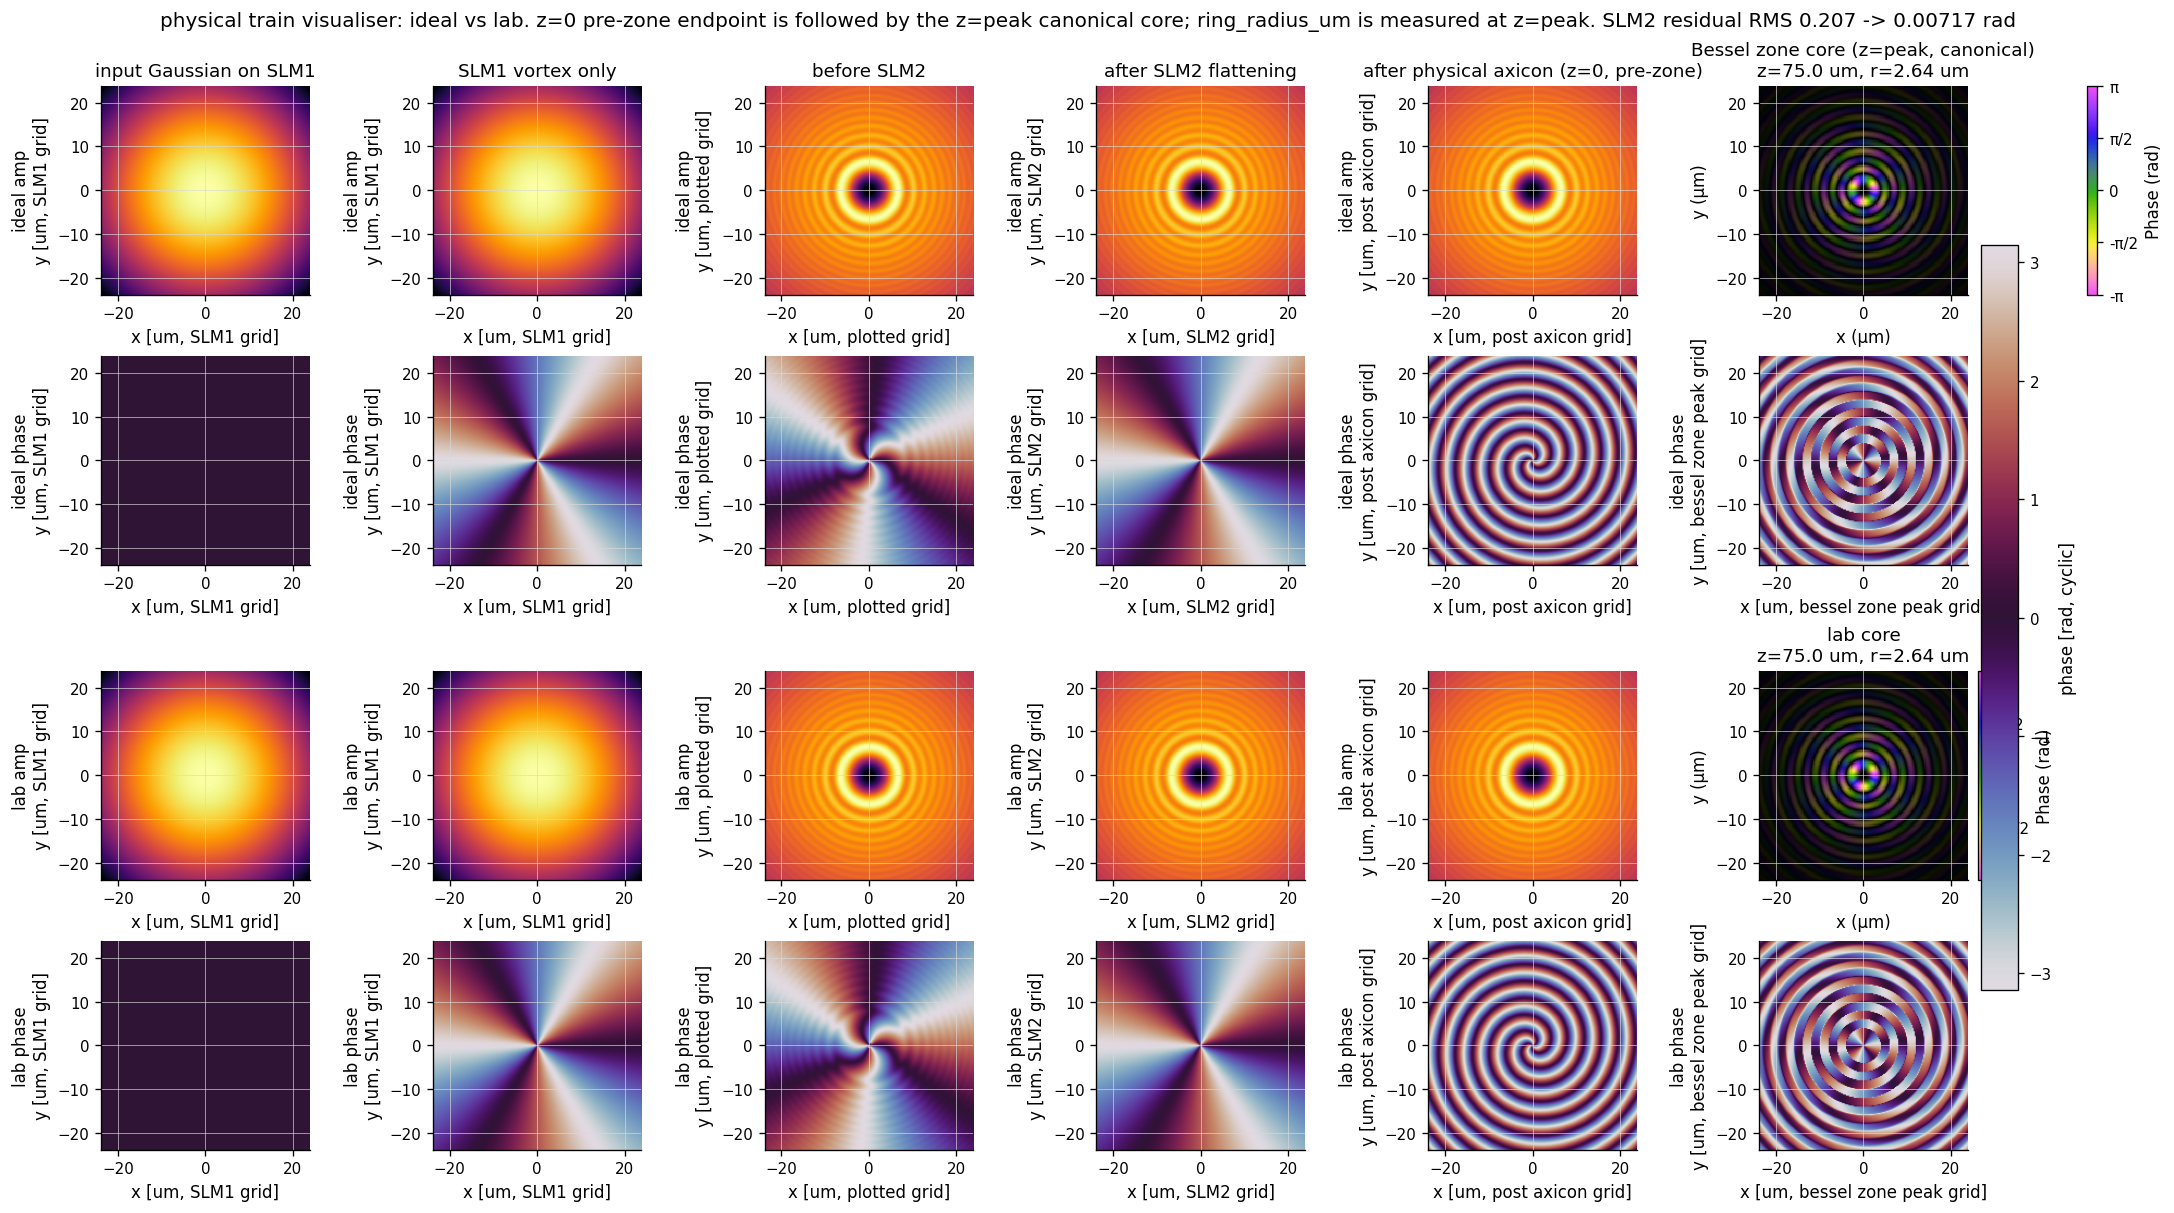

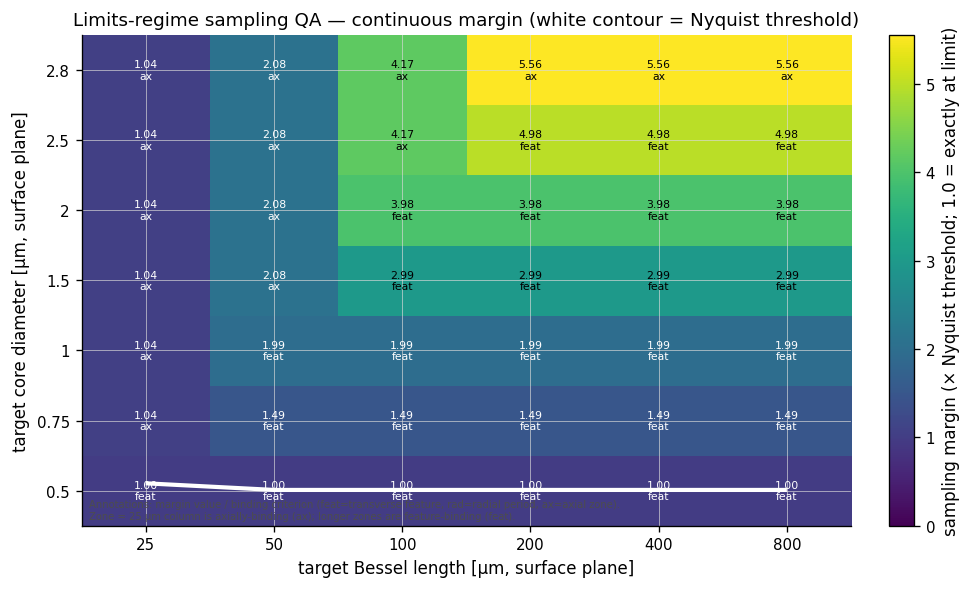

In [5]:
vbb_train_viz.plot_train_visualiser(base, method='physical', output_dir=out_fig)
vbb_train_viz.plot_sampling_qa(base, output_dir=out_fig)